In [1]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import time
from matplotlib.lines import Line2D

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [8]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [20]:
snap, z_list, halo_shot_list100, gal_shot_list100 = np.loadtxt("shotnoise_z_TNG100-1.txt", unpack=True)
snap, z_list, halo_shot_list, gal_shot_list = np.loadtxt("shotnoise_z.txt", unpack=True)
snap_eag, z_list_eag, halo_shot_list_eag, gal_shot_list_eag = np.loadtxt("/cosma/home/dp004/dc-zhan5/eagle/shotnoise_eagle_100.txt", unpack=True)

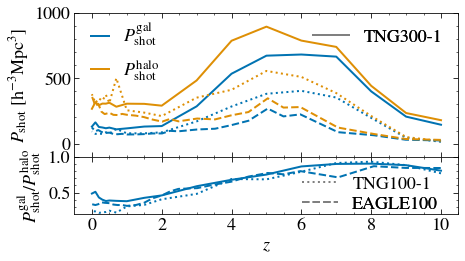

In [37]:
fig1 = plt.figure()
frame1 = fig1.add_axes((.15,.3,.8,.5))
plt.plot(z_list, gal_shot_list, label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", c=palette_tab10[0])
plt.plot(z_list, halo_shot_list, label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", c=palette_tab10[1])


plt.plot(z_list, gal_shot_list100,  linestyle="dotted", c=palette_tab10[0])
plt.plot(z_list, halo_shot_list100, linestyle="dotted", c=palette_tab10[1])

plt.plot(z_list_eag, gal_shot_list_eag,  linestyle="dashed", c=palette_tab10[0])
plt.plot(z_list_eag, halo_shot_list_eag, linestyle="dashed", c=palette_tab10[1])
plt.ylabel("$P_{\mathrm{shot}}\ \mathrm{[h^{-3} Mpc^3]}}$")
ax = plt.gca()
leg = plt.legend(loc="upper left", bbox_to_anchor=(0,1.05), handlelength=1)
ax.add_artist(leg)

solid_line = Line2D([],[],color="grey", linestyle="solid", label="TNG300-1")

leg = ax.legend(handles=[solid_line], loc="upper right", bbox_to_anchor=(1,1))
ax.add_artist(leg)

plt.ylim(-100,1000)
frame2 = fig1.add_axes((.15,.1,.8,.2))

plt.plot(z_list, np.array(gal_shot_list)/np.array(halo_shot_list), label="gal/halo", c=palette_tab10[0])

plt.plot(z_list, np.array(gal_shot_list100)/np.array(halo_shot_list100), label="gal/halo", linestyle="dotted", c=palette_tab10[0])


plt.plot(z_list_eag, np.array(gal_shot_list_eag)/np.array(halo_shot_list_eag), label="gal/halo", linestyle="dashed", c=palette_tab10[0])


plt.ylabel("$P^{\mathrm{gal}}_{\mathrm{shot}}/P^{\mathrm{halo}}_{\mathrm{shot}}$")
plt.xlabel("$z$")
ax = plt.gca()


dotted_line = Line2D([],[],color="grey", linestyle="dotted", label="TNG100-1")

leg = ax.legend(handles=[dotted_line], loc="upper left", bbox_to_anchor=(0.55,0.95))

solid_line = Line2D([],[],color="grey", linestyle="dashed", label="EAGLE100")
ax.add_artist(leg)
leg = ax.legend(handles=[solid_line], loc="upper left", bbox_to_anchor=(0.55,0.6))
ax.add_artist(leg)

plt.ylim(0.2,1)

plt.savefig("../figures/shot_z_w_eagle.pdf", format="pdf", bbox_inches="tight")